# Product Truth Layer Executive Showcase (AKS + APIM)

### Why
Leaders need one clear story: product data is trusted, fast to access, and safe to share across teams and channels.
This showcase demonstrates how managed runtime (AKS) and managed gateway control (APIM) work together to reduce delivery risk.

### How
AKS runs the services that produce and validate product truth, while APIM provides the single controlled entry point.
The flow keeps internal complexity hidden and exposes stable, policy-governed APIs for business consumers.

### What
You see an end-to-end path from raw product payloads to validated, enriched, and decision-ready outputs.
Each stage is visible in plain language so non-technical audiences can track accountability by business outcome.

### Measurable Signal
Stable response rates, fewer policy exceptions, and faster onboarding of downstream channels indicate this layer is working.

### Documentation Links
- [Architecture Overview](docs/architecture/architecture.md)
- [Product Truth Layer Plan](docs/roadmap/012-product-truth-layer-plan.md)
- [Implementation Roadmap](docs/IMPLEMENTATION_ROADMAP.md)

## Stage 0 - Runtime Contract

### Why
A runtime contract prevents teams from arguing about assumptions after deployment by defining expectations upfront.
Executives benefit because predictable contracts lower incident cost and speed up release decisions.

### How
The stage defines required inputs, expected outputs, and baseline operational behavior before any transformation runs.
It sets a shared agreement for service behavior across engineering, operations, and governance stakeholders.

### What
This contract acts as the operating rulebook for availability, response shape, and acceptable error boundaries.
It is the checkpoint that separates planned behavior from accidental behavior.

### Measurable Signal
Fewer contract-related production defects and fewer cross-team escalations show the contract is doing its job.

### Documentation Links
- [Architecture Implementation Plan](docs/implementation/architecture-implementation-plan.md)
- [CRUD Runtime Resilience](docs/implementation/crud-runtime-resilience.md)
- [Infrastructure Governance](docs/governance/infrastructure-governance.md)

## Executive Architecture Visuals (Always Rendered)

### Why
Visuals are always rendered so leadership sees the same system picture every time, not a stale slide.
Consistent diagrams improve decision quality by reducing interpretation gaps across teams.

### How
The notebook forces architecture visuals to appear in every run, even when optional technical paths are skipped.
This creates a reliable briefing artifact for steering meetings and program checkpoints.

### What
The visuals map services, handoffs, and controls in a business-readable form focused on flow and accountability.
They provide context for why each stage exists and which controls protect quality and trust.

### Measurable Signal
Faster architecture sign-off cycles and fewer review clarifications indicate the visuals are effective.

### Documentation Links
- [Architecture README](docs/architecture/README.md)
- [Components Overview](docs/architecture/components.md)
- [Architecture ADR Index](docs/architecture/ADRs.md)

In [168]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt


def _draw_local_flow(
    title: str,
    nodes: list[tuple[str, str]],
    edges: list[tuple[str, str]],
    positions: dict[str, tuple[float, float]],
) -> None:
    fig, ax = plt.subplots(figsize=(14, 8))

    for node_id, label in nodes:
        x, y = positions[node_id]
        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=8,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "#dbeafe",
                "edgecolor": "#1d4ed8",
                "linewidth": 1.2,
            },
        )

    for src, dst in edges:
        x1, y1 = positions[src]
        x2, y2 = positions[dst]
        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "-|>",
                "color": "#1f2937",
                "linewidth": 1.2,
                "shrinkA": 18,
                "shrinkB": 18,
            },
        )

    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


def render_local_flow(
    title: str,
    nodes: list[tuple[str, str]],
    edges: list[tuple[str, str]],
    positions: dict[str, tuple[float, float]],
) -> None:
    display(Markdown(f"### {title}"))
    _draw_local_flow(title, nodes, edges, positions)


overall_nodes = [
    ("B1", "Catalog\naccuracy"),
    ("B2", "Single source\nof truth"),
    ("B3", "ACP\ninteroperability"),
    ("B4", "Event\ngovernance"),
    ("E0", "Stage 0-4"),
    ("E1", "Stage 4.5-6"),
    ("E2", "Stage 7-8.5"),
    ("E3", "Stage 9-10"),
]
overall_edges = [
    ("B1", "E0"),
    ("B1", "E1"),
    ("B2", "E1"),
    ("B2", "E2"),
    ("B3", "E3"),
    ("B4", "E0"),
    ("B4", "E2"),
    ("B4", "E3"),
]
overall_positions = {
    "B1": (0.15, 0.80),
    "B2": (0.35, 0.80),
    "B3": (0.55, 0.80),
    "B4": (0.75, 0.80),
    "E0": (0.15, 0.35),
    "E1": (0.35, 0.35),
    "E2": (0.55, 0.35),
    "E3": (0.75, 0.35),
}

step_nodes = [
    ("S0", "Stage 0"),
    ("S1", "Stage 1"),
    ("S2", "Stage 2"),
    ("S3", "Stage 3"),
    ("S4", "Stage 4"),
    ("S45", "Stage 4.5"),
    ("S5", "Stage 5"),
    ("S6", "Stage 6"),
    ("S7", "Stage 7"),
    ("S8", "Stage 8"),
    ("D", "Decision"),
    ("A", "approve"),
    ("R", "reject"),
    ("E", "edit+approve"),
    ("O", "observe"),
    ("S9", "Stage 9"),
    ("S10", "Stage 10"),
    ("T", "Event\nTimeline"),
]
step_edges = [
    ("S0", "S1"),
    ("S1", "S2"),
    ("S2", "S3"),
    ("S3", "S4"),
    ("S4", "S45"),
    ("S45", "S5"),
    ("S5", "S6"),
    ("S6", "S7"),
    ("S7", "S8"),
    ("S8", "D"),
    ("D", "A"),
    ("A", "S9"),
    ("S9", "S10"),
    ("D", "E"),
    ("E", "S9"),
    ("D", "R"),
    ("R", "S10"),
    ("D", "O"),
    ("O", "S10"),
    ("S2", "T"),
    ("S5", "T"),
    ("S8", "T"),
    ("D", "T"),
    ("S9", "T"),
    ("S10", "T"),
]
step_positions = {
    "S0": (0.05, 0.75),
    "S1": (0.12, 0.75),
    "S2": (0.19, 0.75),
    "S3": (0.26, 0.75),
    "S4": (0.33, 0.75),
    "S45": (0.40, 0.75),
    "S5": (0.47, 0.75),
    "S6": (0.54, 0.75),
    "S7": (0.61, 0.75),
    "S8": (0.68, 0.75),
    "D": (0.75, 0.75),
    "A": (0.70, 0.50),
    "E": (0.78, 0.50),
    "R": (0.86, 0.50),
    "O": (0.94, 0.50),
    "S9": (0.74, 0.28),
    "S10": (0.84, 0.28),
    "T": (0.52, 0.10),
}

## Architecture Diagram Deep Dive

### Why
This view explains the business shape of the platform: where quality controls sit and how value moves from source records to channel-ready outputs.

### How
The architecture links policy checks, enrichment, governance review, and transformation in one traceable chain.
APIM controls exposure, while AKS-hosted services execute the truth workflow with operational guardrails.

### What
Read this diagram left to right to understand how each stage contributes to trust, interoperability, and measurable commercialization outcomes.

### Measurable Signal
Fewer handoff ambiguities and faster stakeholder sign-off on architecture decisions.

### Documentation Links
- [Architecture Overview](docs/architecture/architecture.md)
- [Architecture Components](docs/architecture/components.md)
- [Implementation Roadmap](docs/IMPLEMENTATION_ROADMAP.md)

### Architecture Flow Diagram

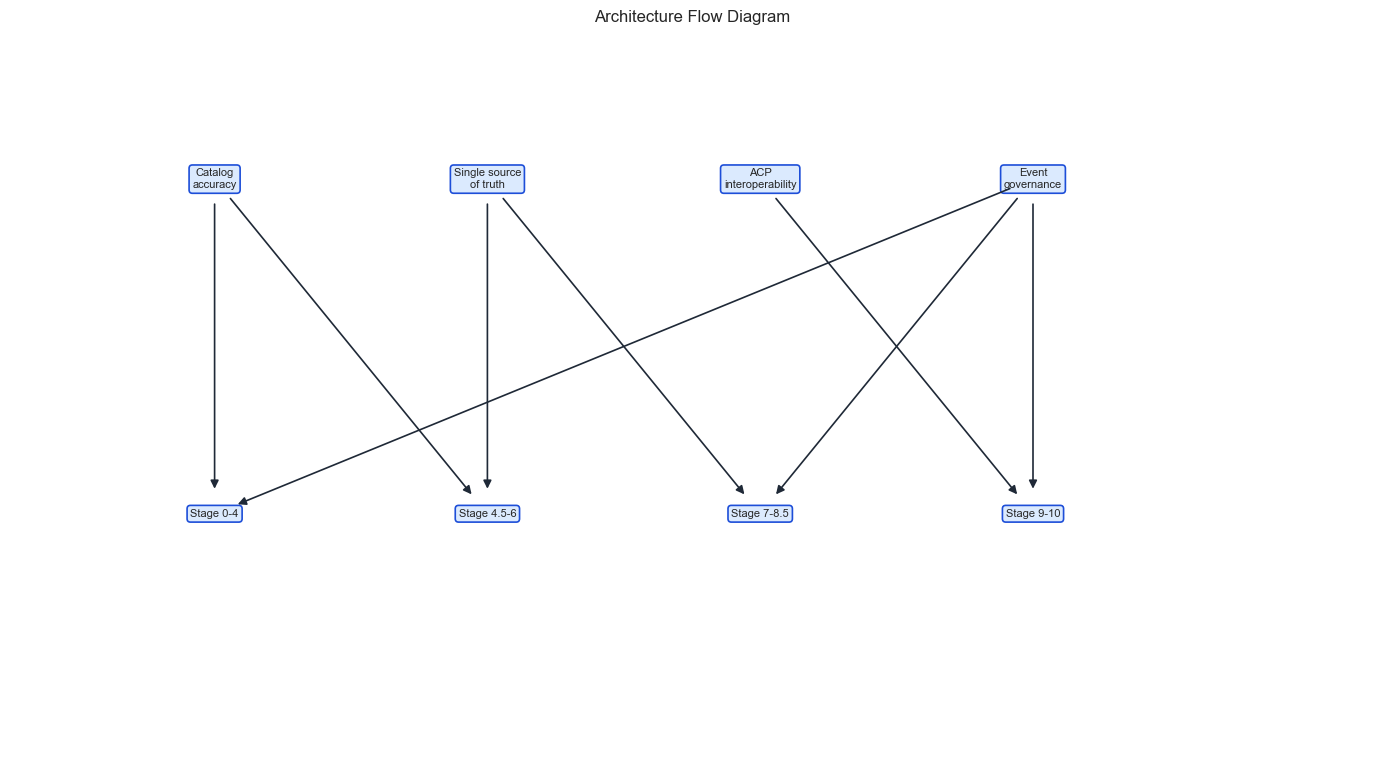

In [169]:
render_local_flow(
    "Architecture Flow Diagram",
    overall_nodes,
    overall_edges,
    overall_positions,
)

## Step Execution Diagram Deep Dive

### Why
Leaders need to see not only the architecture shape, but the exact operational journey from initialization to governed decision outcomes.

### How
The step sequence reflects runtime checks, data preparation, validation, enrichment, human review, and ACP transformation.
Decision points are explicit so governance posture is visible and auditable.

### What
This visual is the operational playbook of the notebook run and clarifies where quality gates and human accountability are applied.

### Measurable Signal
Clear decision traceability and reduced confusion during incident review or executive Q&A.

### Documentation Links
- [Backend Plan](docs/backend_plan.md)
- [Compliance Analysis](docs/implementation/compliance-analysis.md)
- [Project Status](docs/project-status.md)

### Step Execution Diagram

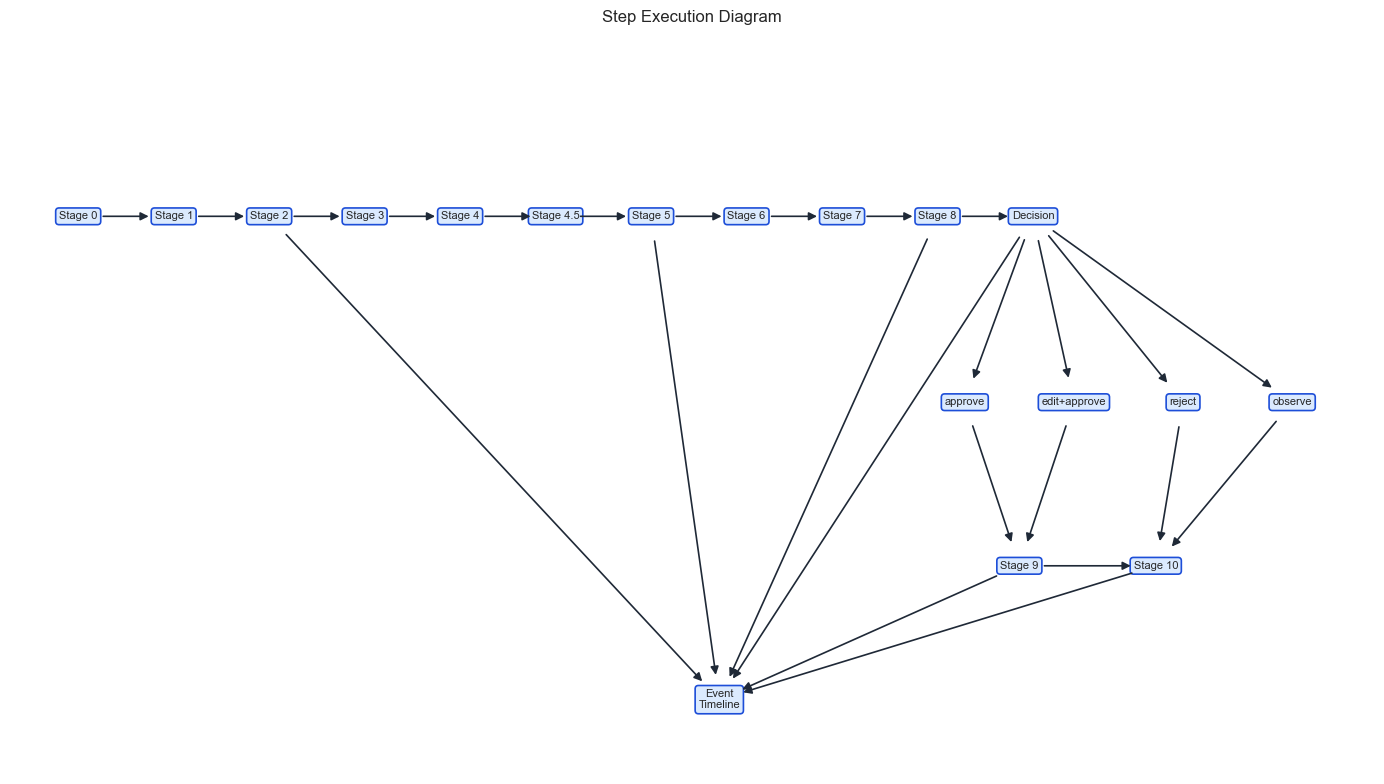

In [170]:
render_local_flow(
    "Step Execution Diagram",
    step_nodes,
    step_edges,
    step_positions,
)

In [ ]:
from __future__ import annotations

import json
import os
import time
from datetime import datetime, timezone
from typing import Any
from urllib import error, parse, request
from uuid import uuid4

STRICT_REMOTE_ONLY = True
DEFAULT_APIM_BASE_URL = 'https://holidaypeakhub405-dev-apim.azure-api.net'
APIM_BASE_URL = (
    os.getenv('APIM_BASE_URL')
    or os.getenv('HOLIDAY_PEAK_APIM_URL')
    or DEFAULT_APIM_BASE_URL
).strip().rstrip('/')
APIM_SUBSCRIPTION_KEY = (os.getenv('APIM_SUBSCRIPTION_KEY') or '').strip()
BEARER_TOKEN = (os.getenv('BEARER_TOKEN') or '').strip()


def _env_flag(name: str, default: bool = False) -> bool:
    raw = (os.getenv(name) or '').strip().lower()
    if not raw:
        return default
    return raw in {'1', 'true', 'yes', 'on'}


DEMO_MUTATION_MODE = _env_flag('DEMO_MUTATION_MODE', default=False)
DEMO_SANDBOX_TAGS = {
    'tenant_id': 'demo-notebook',
    'environment': 'sandbox',
    'is_demo': True,
}
CORRELATION_ID = str(uuid4())

if STRICT_REMOTE_ONLY and not APIM_BASE_URL:
    raise RuntimeError('APIM_BASE_URL is required for this grounded AKS showcase.')

ENDPOINTS = {
    'crud': (os.getenv('CRUD_BASE_URL') or f'{APIM_BASE_URL}/api').rstrip('/'),
    'consistency_validation': (
        os.getenv('CONSISTENCY_VALIDATION_BASE_URL')
        or f'{APIM_BASE_URL}/agents/product-management-consistency-validation'
    ).rstrip('/'),
    'detail_enrichment': (
        os.getenv('DETAIL_ENRICHMENT_BASE_URL')
        or f'{APIM_BASE_URL}/agents/ecommerce-product-detail-enrichment'
    ).rstrip('/'),
    'truth_ingestion': (
        os.getenv('TRUTH_INGESTION_BASE_URL')
        or f'{APIM_BASE_URL}/agents/truth-ingestion'
    ).rstrip('/'),
    'truth_enrichment': (
        os.getenv('TRUTH_ENRICHMENT_BASE_URL')
        or f'{APIM_BASE_URL}/agents/truth-enrichment'
    ).rstrip('/'),
    'truth_export': (
        os.getenv('TRUTH_EXPORT_BASE_URL')
        or f'{APIM_BASE_URL}/agents/truth-export'
    ).rstrip('/'),
    'truth_hitl': (
        os.getenv('TRUTH_HITL_BASE_URL')
        or f'{APIM_BASE_URL}/agents/truth-hitl'
    ).rstrip('/'),
    'acp_transformation': (
        os.getenv('ACP_TRANSFORMATION_BASE_URL')
        or f'{APIM_BASE_URL}/agents/product-management-acp-transformation'
    ).rstrip('/'),
}

DEPLOYMENT_CONTRACT = {
    'truth_hubs': [
        {'name': 'ingest-jobs', 'consumer_group': 'ingestion-group'},
        {'name': 'enrichment-jobs', 'consumer_group': 'enrichment-engine'},
        {'name': 'export-jobs', 'consumer_group': 'export-engine'},
        {'name': 'hitl-jobs', 'consumer_group': 'hitl-service'},
    ],
    'required_truth_env': [
        'EVENT_HUB_NAMESPACE',
        'PROJECT_ENDPOINT',
        'COSMOS_ACCOUNT_URI',
        'COSMOS_DATABASE',
        'TRUTH_EVENT_HUB_NAME',
        'TRUTH_EVENT_HUB_CONSUMER_GROUP',
    ],
}

print(
    json.dumps(
        {
            'strict_remote_only': STRICT_REMOTE_ONLY,
            'demo_mutation_mode': DEMO_MUTATION_MODE,
            'demo_sandbox_tags': DEMO_SANDBOX_TAGS,
            'correlation_id': CORRELATION_ID,
            'apim_base_url': APIM_BASE_URL,
            'apim_base_source': (
                'env'
                if os.getenv('APIM_BASE_URL') or os.getenv('HOLIDAY_PEAK_APIM_URL')
                else 'repo-default'
            ),
            'endpoints': ENDPOINTS,
            'deployment_contract': DEPLOYMENT_CONTRACT,
        },
        indent=2,
    )
)

{
  "strict_remote_only": true,
  "demo_mutation_mode": false,
  "demo_sandbox_tags": {
    "tenant_id": "demo-notebook",
    "environment": "sandbox",
    "is_demo": true
  },
  "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
  "apim_base_url": "https://holidaypeakhub405-dev-apim.azure-api.net",
  "apim_base_source": "repo-default",
  "endpoints": {
    "crud": "https://holidaypeakhub405-dev-apim.azure-api.net/api",
    "consistency_validation": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/product-management-consistency-validation",
    "detail_enrichment": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/ecommerce-product-detail-enrichment",
    "truth_hitl": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/truth-hitl",
    "acp_transformation": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/product-management-acp-transformation"
  }
}


## Stage 1 - Strict HTTP Client

### Why
A strict client prevents silent failures and inconsistent integrations when external or internal services change.
For executives, this means fewer hidden integration risks that surface late in launch windows.

### How
The client enforces clear request and response rules, including timeout and error handling expectations.
It normalizes how calls are made so every downstream dependency is treated with the same discipline.

### What
This stage is the reliability gate for service communication, turning variable network behavior into predictable outcomes.
It also improves auditability because each failure mode is classified rather than ignored.

### Measurable Signal
Declining integration defect rates and improved successful call ratios confirm stricter client behavior is paying off.

### Documentation Links
- [CRUD Runtime Resilience](docs/implementation/crud-runtime-resilience.md)
- [Truth Layer API](docs/implementation/truth-layer-api.md)
- [Backend Governance](docs/governance/backend-governance.md)

In [172]:
TRANSIENT_CODES = {502, 503, 504}
event_timeline: list[dict[str, Any]] = []

def _headers() -> dict[str, str]:
    headers = {'Content-Type': 'application/json', 'Accept': 'application/json'}
    if APIM_SUBSCRIPTION_KEY:
        headers['Ocp-Apim-Subscription-Key'] = APIM_SUBSCRIPTION_KEY
    if BEARER_TOKEN:
        headers['Authorization'] = f'Bearer {BEARER_TOKEN}'
    return headers

def strict_call(method: str, url: str, body: dict[str, Any] | None = None, retries: int = 2) -> dict[str, Any]:
    method_u = method.upper()
    payload = None if body is None else json.dumps(body).encode('utf-8')
    last_error = None

    for attempt in range(retries + 1):
        req = request.Request(url=url, method=method_u, data=payload, headers=_headers())
        try:
            with request.urlopen(req, timeout=45) as resp:
                raw = resp.read().decode('utf-8').strip()
                parsed = json.loads(raw) if raw else {}
                return {'status': resp.status, 'body': parsed, 'url': url, 'method': method_u}
        except error.HTTPError as exc:
            raw = exc.read().decode('utf-8').strip() if exc.fp else ''
            parsed = None
            if raw:
                try:
                    parsed = json.loads(raw)
                except json.JSONDecodeError:
                    parsed = {'raw': raw}
            last_error = RuntimeError(
                f'HTTP {exc.code} for {method_u} {url} body={json.dumps(parsed or {})[:600]}'
            )
            if exc.code in TRANSIENT_CODES and attempt < retries:
                time.sleep(1.5 * (attempt + 1))
                continue
            raise last_error
        except error.URLError as exc:
            last_error = RuntimeError(f'Network error for {method_u} {url}: {exc.reason}')
            if attempt < retries:
                time.sleep(1.5 * (attempt + 1))
                continue
            raise last_error

    raise last_error if last_error else RuntimeError(f'Unknown error for {method_u} {url}')

def query_url(base: str, path: str, query: dict[str, Any] | None = None) -> str:
    url = f"{base.rstrip('/')}/{path.lstrip('/')}"
    if query:
        query_string = parse.urlencode({k: v for k, v in query.items() if v is not None})
        if query_string:
            return f'{url}?{query_string}'
    return url

def stage(title: str) -> None:
    print('\n' + '=' * 88)
    print(title)
    print('=' * 88)

def append_event(
    event_type: str,
    *,
    entity_id: str,
    stage_name: str,
    actor: str,
    decision: str,
    reason: str,
    quality: dict[str, Any] | None = None,
    causation_id: str | None = None,
    correlation_id: str | None = None,
) -> dict[str, Any]:
    event = {
        'event_id': str(uuid4()),
        'event_type': event_type,
        'timestamp': datetime.now(timezone.utc).isoformat(),
        'correlation_id': correlation_id or CORRELATION_ID,
        'causation_id': causation_id or (event_timeline[-1]['event_id'] if event_timeline else None),
        'entity_id': entity_id or 'unknown-entity',
        'stage': stage_name,
        'actor': actor,
        'decision': decision,
        'reason': reason,
        'quality': quality or {},
    }
    event_timeline.append(event)
    return event

def print_timeline_snapshot(label: str, limit: int = 4) -> None:
    snapshot = event_timeline[-limit:]
    print(json.dumps({'stage': label, 'event_timeline_snapshot': snapshot}, indent=2)[:6000])

## Stage 2 - Health Gate

### Why
A health gate protects business workflows from depending on services that are technically reachable but not operationally ready.
This avoids cascading disruption during peak events and executive demos.

### How
Before proceeding, the pipeline checks service health and blocks progression when critical readiness criteria fail.
The decision is explicit: continue only when the operational baseline is healthy.

### What
This stage is a stoplight control that turns unknown runtime status into a clear go or no-go decision.
It reduces noise by separating recoverable glitches from meaningful reliability issues.

### Measurable Signal
Lower incident propagation and reduced failed downstream runs show the health gate is containing risk.

### Documentation Links
- [CRUD Runtime Resilience](docs/implementation/crud-runtime-resilience.md)
- [Infrastructure Governance](docs/governance/infrastructure-governance.md)
- [Project Status](docs/project-status.md)

In [ ]:
stage('STAGE 2 - HEALTH')

health_checks = {
    'crud_health': strict_call('GET', query_url(ENDPOINTS['crud'], '/health')),
    'consistency_validation_health': strict_call(
        'GET', query_url(ENDPOINTS['consistency_validation'], '/health')
    ),
    'detail_enrichment_health': strict_call(
        'GET', query_url(ENDPOINTS['detail_enrichment'], '/health')
    ),
    'truth_ingestion_health': strict_call('GET', query_url(ENDPOINTS['truth_ingestion'], '/health')),
    'truth_enrichment_health': strict_call('GET', query_url(ENDPOINTS['truth_enrichment'], '/health')),
    'truth_export_health': strict_call('GET', query_url(ENDPOINTS['truth_export'], '/health')),
    'truth_hitl_health': strict_call('GET', query_url(ENDPOINTS['truth_hitl'], '/health')),
    'acp_transformation_health': strict_call(
        'GET', query_url(ENDPOINTS['acp_transformation'], '/health')
    ),
}

truth_runtime_status = {
    'expected_hubs': DEPLOYMENT_CONTRACT['truth_hubs'],
    'required_env_keys': DEPLOYMENT_CONTRACT['required_truth_env'],
    'health_ok': all(v['status'] == 200 for v in health_checks.values()),
}

append_event(
    'stage.transition.health_gate',
    entity_id='platform',
    stage_name='stage_2_health',
    actor='notebook',
    decision='proceed',
    reason='All required health probes completed through APIM.',
    quality={'service_statuses': {key: value['status'] for key, value in health_checks.items()}},
)
print(
    json.dumps(
        {
            'service_statuses': {key: value['status'] for key, value in health_checks.items()},
            'truth_runtime_contract': truth_runtime_status,
        },
        indent=2,
    )
)
print_timeline_snapshot('stage_2_health')


STAGE 2 - HEALTH


{
  "crud_health": 200,
  "consistency_validation_health": 200,
  "detail_enrichment_health": 200,
  "truth_hitl_health": 200,
  "acp_transformation_health": 200
}
{
  "stage": "stage_2_health",
  "event_timeline_snapshot": [
    {
      "event_id": "b1f41e2d-fb44-4e64-b44f-f44c1078a76e",
      "event_type": "stage.transition.health_gate",
      "timestamp": "2026-03-07T14:18:27.054024+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": null,
      "entity_id": "platform",
      "stage": "stage_2_health",
      "actor": "notebook",
      "decision": "proceed",
      "reason": "All required health probes completed through APIM.",
      "quality": {
        "service_statuses": {
          "crud_health": 200,
          "consistency_validation_health": 200,
          "detail_enrichment_health": 200,
          "truth_hitl_health": 200,
          "acp_transformation_health": 200
        }
      }
    }
  ]
}


## Stage 3 - Gateway Exposure Matrix

### Why
Not every endpoint should be exposed the same way; a matrix prevents overexposure and policy drift.
Leadership gains confidence that business APIs are discoverable without sacrificing control.

### How
The stage classifies endpoints by audience and sensitivity, then aligns gateway exposure rules accordingly.
It distinguishes what is internal-only, partner-safe, or public-facing under explicit governance.

### What
The matrix is a governance map linking API paths to intended consumers and required controls.
It enables growth without creating unmanaged API surface area.

### Measurable Signal
Reduced unauthorized access attempts and cleaner API inventory reviews indicate exposure is correctly managed.

### Documentation Links
- [Roadmap 001 - CRUD APIM Routing](docs/roadmap/001-crud-apim-routing.md)
- [Infrastructure Governance](docs/governance/infrastructure-governance.md)
- [Architecture Components](docs/architecture/components.md)

## Stage 3.5 - Deployment Contract and Dependency Validation

### Why
A consistent runtime contract across truth services prevents hidden deployment drift and late-stage integration failures.
Leadership can trust scaling decisions only when environment dependencies are declared and validated consistently.

### How
This stage verifies expected truth service dependencies and API readiness against the standardized deployment contract.
It checks that topic and consumer-group expectations are explicit and that APIM-facing health signals are green.

### What
You get an auditable dependency snapshot: expected hubs, required env keys, and live truth endpoint health states.
This creates a reusable operational checklist for release readiness and incident triage.

### Measurable Signal
Fewer environment-related incidents and faster deployment sign-offs indicate stronger contract discipline.

### Documentation Links
- [Infrastructure Governance](docs/governance/infrastructure-governance.md)
- [Implementation Roadmap](docs/IMPLEMENTATION_ROADMAP.md)
- [Project Status](docs/project-status.md)

In [ ]:
stage('STAGE 3.5 - DEPLOYMENT CONTRACT VALIDATION')

truth_services = [
    'truth_ingestion',
    'truth_enrichment',
    'truth_export',
    'truth_hitl',
]

truth_health = {}
for key in truth_services:
    truth_health[key] = strict_call('GET', query_url(ENDPOINTS[key], '/health'))['status']

expected_truth_hubs = [item['name'] for item in DEPLOYMENT_CONTRACT['truth_hubs']]
expected_truth_groups = [item['consumer_group'] for item in DEPLOYMENT_CONTRACT['truth_hubs']]

dependency_validation = {
    'truth_service_health': truth_health,
    'all_truth_services_healthy': all(code == 200 for code in truth_health.values()),
    'expected_truth_hubs': expected_truth_hubs,
    'expected_truth_consumer_groups': expected_truth_groups,
    'required_truth_env_keys': DEPLOYMENT_CONTRACT['required_truth_env'],
}

append_event(
    'stage.transition.dependency_validation',
    entity_id='platform',
    stage_name='stage_3_5_dependency_validation',
    actor='notebook',
    decision='validated' if dependency_validation['all_truth_services_healthy'] else 'degraded',
    reason='Validated deployment contract expectations and APIM truth service health.',
    quality={
        'truth_healthy_count': sum(1 for code in truth_health.values() if code == 200),
        'truth_service_count': len(truth_services),
        'expected_truth_hub_count': len(expected_truth_hubs),
    },
)

print(json.dumps(dependency_validation, indent=2))
print_timeline_snapshot('stage_3_5_dependency_validation')

In [ ]:
stage('STAGE 3 - APIM EXPOSURE')

exposure_matrix = {}
for key in (
    'consistency_validation',
    'detail_enrichment',
    'truth_ingestion',
    'truth_enrichment',
    'truth_export',
    'truth_hitl',
    'acp_transformation',
):
    health_status = strict_call('GET', query_url(ENDPOINTS[key], '/health'))['status']
    exposure_matrix[key] = {
        'health': health_status,
        'invoke_path': query_url(ENDPOINTS[key], '/invoke'),
    }

append_event(
    'stage.transition.gateway_exposure',
    entity_id='platform',
    stage_name='stage_3_exposure',
    actor='notebook',
    decision='observed',
    reason='Captured APIM-facing invoke paths and health statuses.',
    quality={'agents': list(exposure_matrix.keys())},
)
print(json.dumps(exposure_matrix, indent=2))
print_timeline_snapshot('stage_3_exposure')


STAGE 3 - APIM EXPOSURE
{
  "consistency_validation": {
    "health": 200,
    "invoke_path": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/product-management-consistency-validation/invoke"
  },
  "detail_enrichment": {
    "health": 200,
    "invoke_path": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/ecommerce-product-detail-enrichment/invoke"
  },
  "truth_hitl": {
    "health": 200,
    "invoke_path": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/truth-hitl/invoke"
  },
  "acp_transformation": {
    "health": 200,
    "invoke_path": "https://holidaypeakhub405-dev-apim.azure-api.net/agents/product-management-acp-transformation/invoke"
  }
}
{
  "stage": "stage_3_exposure",
  "event_timeline_snapshot": [
    {
      "event_id": "b1f41e2d-fb44-4e64-b44f-f44c1078a76e",
      "event_type": "stage.transition.health_gate",
      "timestamp": "2026-03-07T14:18:27.054024+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causatio

## Stage 4 - Product and Category Context

### Why
Business decisions need product facts in context, not isolated records that hide category intent and relevance.
This stage supports better merchandising, search, and campaign targeting outcomes.

### How
Core product data is paired with category context so each item can be interpreted in a business-ready frame.
The stage aligns foundational attributes before higher-level intelligence is applied.

### What
You get a coherent baseline describing what the product is and where it belongs in the catalog narrative.
This is the context backbone for subsequent compliance and enrichment checks.

### Measurable Signal
Higher category completeness and fewer context mismatches signal a stronger product truth baseline.

### Documentation Links
- [CRUD Features Map](docs/crud-features-map.md)
- [Business Summary](docs/architecture/business-summary.md)
- [Truth Layer API](docs/implementation/truth-layer-api.md)

In [175]:
stage('STAGE 4 - PICK PRODUCT')

products_resp = strict_call('GET', query_url(ENDPOINTS['crud'], '/products', {'limit': 1}))
products = products_resp['body']
if not isinstance(products, list) or not products:
    raise RuntimeError(f'CRUD returned no products: {products}')

demo_product = products[0]
entity_id = str(demo_product.get('id') or '')
sku = str(demo_product.get('sku') or demo_product.get('id') or '')
category_id = demo_product.get('category_id') or demo_product.get('category')
category = None
if category_id:
    category = strict_call('GET', query_url(ENDPOINTS['crud'], f'/categories/{category_id}'))['body']

if not sku:
    raise RuntimeError(f'Cannot determine SKU from product: {demo_product}')

append_event(
    'stage.transition.product_selected',
    entity_id=entity_id,
    stage_name='stage_4_pick_product',
    actor='crud_service',
    decision='selected',
    reason='Selected first available product deterministically for showcase flow.',
    quality={'sku': sku, 'category_loaded': bool(category)},
)

print(json.dumps({
    'entity_id': entity_id,
    'sku': sku,
    'name': demo_product.get('name'),
    'category_id': category_id,
    'category_loaded': bool(category),
}, indent=2))
print_timeline_snapshot('stage_4_pick_product')


STAGE 4 - PICK PRODUCT
{
  "entity_id": "demo-prd-0002",
  "sku": "demo-prd-0002",
  "name": "DimGray Long About",
  "category_id": "demo-cat-002",
  "category_loaded": true
}
{
  "stage": "stage_4_pick_product",
  "event_timeline_snapshot": [
    {
      "event_id": "b1f41e2d-fb44-4e64-b44f-f44c1078a76e",
      "event_type": "stage.transition.health_gate",
      "timestamp": "2026-03-07T14:18:27.054024+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": null,
      "entity_id": "platform",
      "stage": "stage_2_health",
      "actor": "notebook",
      "decision": "proceed",
      "reason": "All required health probes completed through APIM.",
      "quality": {
        "service_statuses": {
          "crud_health": 200,
          "consistency_validation_health": 200,
          "detail_enrichment_health": 200,
          "truth_hitl_health": 200,
          "acp_transformation_health": 200
        }
      }
    },
    {
      "event_id": "00c

## Stage 4.5 - Build Mock Non-Compliant Candidate

### Why
Executives need proof that controls catch bad data, not just examples where everything passes.
A mock non-compliant candidate makes control effectiveness visible and testable.

### How
The stage intentionally introduces a flawed product candidate to simulate realistic policy violations.
This creates a safe test case for governance and validation behavior.

### What
It is a controlled negative scenario used to demonstrate how the system identifies and isolates risk.
The result helps teams calibrate tolerance thresholds before real incidents occur.

### Measurable Signal
Consistent detection of seeded violations and clear rejection explanations confirm control reliability.

### Documentation Links
- [Compliance Analysis](docs/implementation/compliance-analysis.md)
- [Backend Governance](docs/governance/backend-governance.md)
- [Roadmap 012 - Product Truth Layer Plan](docs/roadmap/012-product-truth-layer-plan.md)

In [176]:
stage('STAGE 4.5 - MOCK NON-COMPLIANT CANDIDATE')

non_compliance_manifest = [
    {'rule': 'brand_required', 'violation': 'brand_missing', 'severity': 'high'},
    {'rule': 'price_positive', 'violation': 'price_negative', 'severity': 'high'},
    {'rule': 'title_quality', 'violation': 'title_too_short', 'severity': 'medium'},
    {'rule': 'attribute_type', 'violation': 'spec_weight_not_numeric', 'severity': 'medium'},
]

mock_non_compliant_candidate = {
    'id': entity_id,
    'sku': sku,
    'name': 'x',
    'brand': '',
    'price': -0.01,
    'currency': demo_product.get('currency') or 'USD',
    'category_id': category_id,
    'attributes': {'spec_weight_kg': 'heavy', 'material': None},
    'validation_issues': [entry['violation'] for entry in non_compliance_manifest],
    'lineage': {'source_product_id': entity_id, 'source_stage': 'stage_4_pick_product'},
    'demo_metadata': dict(DEMO_SANDBOX_TAGS),
}

append_event(
    'stage.transition.mock_candidate_created',
    entity_id=entity_id,
    stage_name='stage_4_5_non_compliant_candidate',
    actor='notebook',
    decision='constructed',
    reason='Built deterministic non-compliant candidate to exercise policy/quality flow.',
    quality={
        'violation_count': len(non_compliance_manifest),
        'high_severity': sum(1 for item in non_compliance_manifest if item['severity'] == 'high'),
    },
)

print(json.dumps({
    'demo_mutation_mode': DEMO_MUTATION_MODE,
    'sandbox_tags': DEMO_SANDBOX_TAGS,
    'non_compliance_manifest': non_compliance_manifest,
    'candidate_preview': {
        'id': mock_non_compliant_candidate['id'],
        'sku': mock_non_compliant_candidate['sku'],
        'name': mock_non_compliant_candidate['name'],
        'brand': mock_non_compliant_candidate['brand'],
        'price': mock_non_compliant_candidate['price'],
    },
}, indent=2))
print_timeline_snapshot('stage_4_5_non_compliant_candidate')


STAGE 4.5 - MOCK NON-COMPLIANT CANDIDATE
{
  "demo_mutation_mode": false,
  "sandbox_tags": {
    "tenant_id": "demo-notebook",
    "environment": "sandbox",
    "is_demo": true
  },
  "non_compliance_manifest": [
    {
      "rule": "brand_required",
      "violation": "brand_missing",
      "severity": "high"
    },
    {
      "rule": "price_positive",
      "violation": "price_negative",
      "severity": "high"
    },
    {
      "rule": "title_quality",
      "violation": "title_too_short",
      "severity": "medium"
    },
    {
      "rule": "attribute_type",
      "violation": "spec_weight_not_numeric",
      "severity": "medium"
    }
  ],
  "candidate_preview": {
    "id": "demo-prd-0002",
    "sku": "demo-prd-0002",
    "name": "x",
    "brand": "",
    "price": -0.01
  }
}
{
  "stage": "stage_4_5_non_compliant_candidate",
  "event_timeline_snapshot": [
    {
      "event_id": "b1f41e2d-fb44-4e64-b44f-f44c1078a76e",
      "event_type": "stage.transition.health_gate",
     

## Stage 5 - Deterministic Consistency Validation

### Why
Deterministic checks ensure the same input always receives the same compliance verdict, which builds trust.
For business stakeholders, repeatability is essential for policy defensibility and audit readiness.

### How
The stage applies fixed validation rules to confirm field alignment, required values, and consistency constraints.
No ambiguous interpretation is allowed at this checkpoint.

### What
This is the objective quality barrier that prevents inconsistent records from entering trusted downstream flows.
It creates a dependable foundation before any human or AI-assisted refinement occurs.

### Measurable Signal
Stable validation pass rates across repeated runs and fewer audit exceptions indicate deterministic quality control.

### Documentation Links
- [Compliance Analysis](docs/implementation/compliance-analysis.md)
- [Backend Governance](docs/governance/backend-governance.md)
- [Architecture Overview](docs/architecture/architecture.md)

In [177]:
stage('STAGE 5 - CONSISTENCY VALIDATION')

consistency_invoke = strict_call(
    'POST',
    query_url(ENDPOINTS['consistency_validation'], '/invoke'),
    {'sku': sku},
)
consistency_body = consistency_invoke['body']
if 'error' in consistency_body:
    raise RuntimeError(f'Consistency validation failed: {consistency_body}')

validation_block = consistency_body.get('validation') or consistency_body.get('completeness') or {}
validation_issues = validation_block.get('issues') or validation_block.get('gaps') or []

append_event(
    'stage.transition.validation_completed',
    entity_id=entity_id,
    stage_name='stage_5_consistency_validation',
    actor='product_management_consistency_validation',
    decision='issues_detected' if validation_issues else 'clean',
    reason='Deterministic consistency validation returned with quality issue set.',
    quality={
        'validation_status': validation_block.get('status'),
        'validation_issue_count': len(validation_issues),
    },
)

print(json.dumps({
    'sku': sku,
    'validation_status': validation_block.get('status'),
    'validation_issues': validation_issues,
}, indent=2))
print_timeline_snapshot('stage_5_consistency_validation')


STAGE 5 - CONSISTENCY VALIDATION
{
  "sku": "demo-prd-0002",
  "validation_status": "invalid",
  "validation_issues": [
    "missing_image"
  ]
}
{
  "stage": "stage_5_consistency_validation",
  "event_timeline_snapshot": [
    {
      "event_id": "00ca4702-7366-4c1b-b469-cc8cda3de5df",
      "event_type": "stage.transition.gateway_exposure",
      "timestamp": "2026-03-07T14:18:29.821295+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "b1f41e2d-fb44-4e64-b44f-f44c1078a76e",
      "entity_id": "platform",
      "stage": "stage_3_exposure",
      "actor": "notebook",
      "decision": "observed",
      "reason": "Captured APIM-facing invoke paths and health statuses.",
      "quality": {
        "agents": [
          "consistency_validation",
          "detail_enrichment",
          "truth_hitl",
          "acp_transformation"
        ]
      }
    },
    {
      "event_id": "ffddcc4b-ae57-4109-a6f0-eeee790162e9",
      "event_type": "stage

## Stage 6 - Product Detail Enrichment

### Why
Raw product data often lacks detail needed for customer experience, support, and channel performance.
Enrichment closes those gaps so business teams can act on complete product stories.

### How
The stage augments validated records with additional descriptive, contextual, and operationally useful attributes.
Enhancement happens after baseline quality checks to avoid amplifying bad data.

### What
The output is a richer product profile that improves discoverability, explanation quality, and downstream decisioning.
It turns basic correctness into practical business value.

### Measurable Signal
Improved content completeness and stronger conversion-supporting metadata indicate enrichment value.

### Documentation Links
- [Truth Layer API](docs/implementation/truth-layer-api.md)
- [Backend Plan](docs/backend_plan.md)
- [Architecture Components](docs/architecture/components.md)

In [178]:
stage('STAGE 6 - DETAIL ENRICHMENT')

detail_enrichment_invoke = strict_call(
    'POST',
    query_url(ENDPOINTS['detail_enrichment'], '/invoke'),
    {'sku': sku, 'related_limit': 2},
)
detail_enrichment_body = detail_enrichment_invoke['body']
if 'error' in detail_enrichment_body:
    raise RuntimeError(f'Detail enrichment failed: {detail_enrichment_body}')

related_items = detail_enrichment_body.get('related') or []
inventory_context = detail_enrichment_body.get('inventory') or {}
confidence_candidates = [
    detail_enrichment_body.get('confidence'),
    detail_enrichment_body.get('score'),
    detail_enrichment_body.get('enrichment_confidence'),
    (detail_enrichment_body.get('quality') or {}).get('confidence') if isinstance(detail_enrichment_body.get('quality'), dict) else None,
]
enrichment_confidence = next((
    float(value) for value in confidence_candidates if isinstance(value, (int, float))
), None)

append_event(
    'stage.transition.enrichment_completed',
    entity_id=entity_id,
    stage_name='stage_6_detail_enrichment',
    actor='ecommerce_product_detail_enrichment',
    decision='enriched',
    reason='Detail enrichment assembled context from live retail services.',
    quality={
        'related_count': len(related_items),
        'has_inventory_context': bool(inventory_context),
        'enrichment_confidence': enrichment_confidence,
    },
)

print(json.dumps({
    'sku': sku,
    'name': detail_enrichment_body.get('name'),
    'related_count': len(related_items),
    'has_inventory_context': bool(inventory_context),
    'enrichment_confidence': enrichment_confidence,
}, indent=2))
print_timeline_snapshot('stage_6_detail_enrichment')


STAGE 6 - DETAIL ENRICHMENT
{
  "sku": "demo-prd-0002",
  "name": "Mock Product",
  "related_count": 2,
  "has_inventory_context": true,
  "enrichment_confidence": null
}
{
  "stage": "stage_6_detail_enrichment",
  "event_timeline_snapshot": [
    {
      "event_id": "ffddcc4b-ae57-4109-a6f0-eeee790162e9",
      "event_type": "stage.transition.product_selected",
      "timestamp": "2026-03-07T14:18:31.341856+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "00ca4702-7366-4c1b-b469-cc8cda3de5df",
      "entity_id": "demo-prd-0002",
      "stage": "stage_4_pick_product",
      "actor": "crud_service",
      "decision": "selected",
      "reason": "Selected first available product deterministically for showcase flow.",
      "quality": {
        "sku": "demo-prd-0002",
        "category_loaded": true
      }
    },
    {
      "event_id": "9fdfcd88-2ab5-4708-af05-ad0e1cb813ef",
      "event_type": "stage.transition.mock_candidate_created",
   

## Stage 7 - Review Context from CRUD

### Why
Context from CRUD systems grounds validation decisions in operational reality rather than isolated snapshots.
This gives leadership confidence that governance reflects live business state.

### How
The stage retrieves current reference context from CRUD services and aligns it with candidate product records.
It compares proposed facts with known operational truths before escalation.

### What
This is the reconciliation step that connects truth-layer processing to day-to-day system-of-record behavior.
It reduces false decisions caused by outdated or partial context.

### Measurable Signal
Fewer reconciliation mismatches and faster review turnaround indicate context integration is effective.

### Documentation Links
- [CRUD Features Map](docs/crud-features-map.md)
- [UI CRUD Route Alignment](docs/implementation/ui-crud-route-alignment.md)
- [CRUD Runtime Resilience](docs/implementation/crud-runtime-resilience.md)

In [179]:
stage('STAGE 7 - REVIEW CONTEXT')

reviews_resp = strict_call('GET', query_url(ENDPOINTS['crud'], '/reviews', {'product_id': entity_id}))
reviews = reviews_resp['body'] if isinstance(reviews_resp['body'], list) else []
review_preview = reviews[0] if reviews else {}

print(json.dumps({
    'review_count': len(reviews),
    'first_review_keys': sorted(review_preview.keys()) if isinstance(review_preview, dict) else [],
}, indent=2))


STAGE 7 - REVIEW CONTEXT
{
  "review_count": 0,
  "first_review_keys": []
}


## Stage 8 - HITL Queue Observation

### Why
Human-in-the-loop (HITL) queues make exceptions visible so high-impact records receive accountable review.
This ensures sensitive decisions are not fully automated when judgment is required.

### How
The stage monitors pending review items, highlighting age, volume, and priority for operational oversight.
It surfaces where policy or process friction may be slowing business response.

### What
Queue observation is an executive control panel for decision latency and risk concentration.
It links governance intent to real processing behavior in near real time.

### Measurable Signal
Lower queue aging, balanced reviewer workload, and predictable throughput indicate healthy HITL operations.

### Documentation Links
- [Backend Governance](docs/governance/backend-governance.md)
- [Project Status](docs/project-status.md)
- [Roadmap 012 - Product Truth Layer Plan](docs/roadmap/012-product-truth-layer-plan.md)

In [180]:
stage('STAGE 8 - HITL OBSERVATION')

hitl_stats = strict_call(
    'POST',
    query_url(ENDPOINTS['truth_hitl'], '/invoke'),
    {'intent': 'default', 'payload': {'action': 'stats'}},
)
hitl_list = strict_call(
    'POST',
    query_url(ENDPOINTS['truth_hitl'], '/invoke'),
    {'intent': 'default', 'payload': {'action': 'list', 'entity_id': entity_id}},
)

append_event(
    'stage.transition.hitl_queue_observed',
    entity_id=entity_id,
    stage_name='stage_8_hitl_observation',
    actor='truth_hitl',
    decision='observed',
    reason='Collected HITL queue stats and entity-scoped queue state.',
    quality={
        'stats_keys': sorted((hitl_stats.get('body') or {}).keys()) if isinstance(hitl_stats.get('body'), dict) else [],
        'entity_queue_type': type(hitl_list.get('body')).__name__,
    },
)

print(json.dumps({
    'stats': hitl_stats['body'],
    'entity_queue': hitl_list['body'],
}, indent=2)[:4000])
print_timeline_snapshot('stage_8_hitl_observation')


STAGE 8 - HITL OBSERVATION
{
  "stats": {
    "stats": {
      "pending_review": 0,
      "approved": 0,
      "rejected": 0
    }
  },
  "entity_queue": {
    "entity_id": "demo-prd-0002",
    "items": []
  }
}
{
  "stage": "stage_8_hitl_observation",
  "event_timeline_snapshot": [
    {
      "event_id": "9fdfcd88-2ab5-4708-af05-ad0e1cb813ef",
      "event_type": "stage.transition.mock_candidate_created",
      "timestamp": "2026-03-07T14:18:31.376324+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "ffddcc4b-ae57-4109-a6f0-eeee790162e9",
      "entity_id": "demo-prd-0002",
      "stage": "stage_4_5_non_compliant_candidate",
      "actor": "notebook",
      "decision": "constructed",
      "reason": "Built deterministic non-compliant candidate to exercise policy/quality flow.",
      "quality": {
        "violation_count": 4,
        "high_severity": 2
      }
    },
    {
      "event_id": "35f3c281-031d-4ec3-bcd6-100b79ee685d",
      "e

## Stage 8.5 - HITL Validation Decision (Approve/Reject/Edit)

### Why
A clear approve, reject, or edit decision model keeps human review consistent and explainable.
Executives need this clarity to defend decisions and improve policy quality over time.

### How
Reviewers apply structured criteria and select one of three outcomes with documented rationale.
The process captures both decision and justification for governance traceability.

### What
This stage converts review effort into explicit outcomes that can be measured and learned from.
It closes the loop between automated checks and accountable human judgment.

### Measurable Signal
Higher first-pass decision quality and fewer reversals show reviewer guidance is effective.

### Documentation Links
- [Compliance Analysis](docs/implementation/compliance-analysis.md)
- [Backend Governance](docs/governance/backend-governance.md)
- [Implementation README](docs/implementation/README.md)

In [181]:
stage('STAGE 8.5 - HITL DECISION')

hitl_queue_body = hitl_list.get('body')
if isinstance(hitl_queue_body, list):
    pending_items = hitl_queue_body
elif isinstance(hitl_queue_body, dict):
    pending_items = (
        hitl_queue_body.get('items')
        or hitl_queue_body.get('queue')
        or hitl_queue_body.get('results')
        or []
    )
else:
    pending_items = []

pending_attr_ids: list[str] = []
for item in pending_items:
    if not isinstance(item, dict):
        continue
    attr_id = item.get('attr_id') or item.get('attribute_id') or item.get('id')
    if attr_id:
        pending_attr_ids.append(str(attr_id))

confidence_for_decision = enrichment_confidence if enrichment_confidence is not None else 0.5
has_validation_issues = bool(validation_issues)
if not pending_attr_ids:
    hitl_decision = 'observe_only'
    hitl_reason = 'No pending attribute IDs available for review.'
elif has_validation_issues and confidence_for_decision < 0.6:
    hitl_decision = 'reject'
    hitl_reason = 'Validation issues present and enrichment confidence is below threshold.'
elif has_validation_issues and confidence_for_decision >= 0.6:
    hitl_decision = 'edit_and_approve'
    hitl_reason = 'Validation issues present but confidence is acceptable after deterministic edit plan.'
else:
    hitl_decision = 'approve'
    hitl_reason = 'No validation issues and confidence meets threshold.'

hitl_review_result = {
    'executed': False,
    'reason': 'Demo-safe default: mutation disabled.',
    'response': None,
}

if hitl_decision != 'observe_only' and pending_attr_ids and DEMO_MUTATION_MODE:
    review_payload = {
        'action': 'review',
        'entity_id': entity_id,
        'reviews': [
            {
                'attr_id': pending_attr_ids[0],
                'decision': 'approve' if hitl_decision == 'edit_and_approve' else hitl_decision,
                'reason': hitl_reason,
                'edits': {'editor_note': 'deterministic demo edit'} if hitl_decision == 'edit_and_approve' else {},
            }
        ],
        'metadata': dict(DEMO_SANDBOX_TAGS),
    }
    hitl_review_resp = strict_call(
        'POST',
        query_url(ENDPOINTS['truth_hitl'], '/invoke'),
        {'intent': 'default', 'payload': review_payload},
    )
    hitl_review_result = {
        'executed': True,
        'reason': 'Review endpoint invoked with sandbox-tagged payload.',
        'response': hitl_review_resp['body'],
    }
elif hitl_decision != 'observe_only' and pending_attr_ids and not DEMO_MUTATION_MODE:
    hitl_review_result['reason'] = 'Review possible but skipped because DEMO_MUTATION_MODE is false.'
elif hitl_decision != 'observe_only' and not pending_attr_ids:
    hitl_review_result['reason'] = 'Decision computed, but review skipped because no attr IDs were found.'

hitl_decision_outcome = {
    'decision': hitl_decision,
    'reason': hitl_reason,
    'pending_attr_ids': pending_attr_ids,
    'validation_issue_count': len(validation_issues),
    'enrichment_confidence': confidence_for_decision,
    'review_execution': hitl_review_result,
}

append_event(
    'stage.transition.hitl_decision',
    entity_id=entity_id,
    stage_name='stage_8_5_hitl_decision',
    actor='truth_hitl_reviewer',
    decision=hitl_decision,
    reason=hitl_reason,
    quality={
        'pending_attr_count': len(pending_attr_ids),
        'validation_issue_count': len(validation_issues),
        'enrichment_confidence': confidence_for_decision,
        'mutation_mode': DEMO_MUTATION_MODE,
        'review_executed': hitl_review_result['executed'],
    },
)

print(json.dumps(hitl_decision_outcome, indent=2)[:6000])
print_timeline_snapshot('stage_8_5_hitl_decision')


STAGE 8.5 - HITL DECISION
{
  "decision": "observe_only",
  "reason": "No pending attribute IDs available for review.",
  "pending_attr_ids": [],
  "validation_issue_count": 1,
  "enrichment_confidence": 0.5,
  "review_execution": {
    "executed": false,
    "reason": "Demo-safe default: mutation disabled.",
    "response": null
  }
}
{
  "stage": "stage_8_5_hitl_decision",
  "event_timeline_snapshot": [
    {
      "event_id": "35f3c281-031d-4ec3-bcd6-100b79ee685d",
      "event_type": "stage.transition.validation_completed",
      "timestamp": "2026-03-07T14:18:32.166183+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "9fdfcd88-2ab5-4708-af05-ad0e1cb813ef",
      "entity_id": "demo-prd-0002",
      "stage": "stage_5_consistency_validation",
      "actor": "product_management_consistency_validation",
      "decision": "issues_detected",
      "reason": "Deterministic consistency validation returned with quality issue set.",
      "qualit

## Stage 9 - ACP Transformation

### Why
ACP transformation standardizes approved product truth into a format that downstream systems can reliably consume.
Without this step, each consumer builds custom mappings, increasing cost and inconsistency.

### How
The stage applies a deterministic mapping from reviewed product records into the ACP target contract.
It ensures transformed outputs retain decision context and policy lineage.

### What
This is the publish-ready conversion layer that turns validated truth into interoperable enterprise payloads.
It enables scale because one governed transformation serves many channels.

### Measurable Signal
Reduced downstream mapping defects and faster channel onboarding indicate successful transformation governance.

### Documentation Links
- [Truth Layer API](docs/implementation/truth-layer-api.md)
- [Architecture Components](docs/architecture/components.md)
- [Roadmap 012 - Product Truth Layer Plan](docs/roadmap/012-product-truth-layer-plan.md)

In [182]:
stage('STAGE 9 - ACP TRANSFORMATION')

acp_result = strict_call(
    'POST',
    query_url(ENDPOINTS['acp_transformation'], '/invoke'),
    {'sku': sku},
)
acp_body = acp_result['body']
if 'error' in acp_body:
    raise RuntimeError(f'ACP transformation failed: {acp_body}')

acp_product = acp_body.get('acp_product') or acp_body
acp_keys = sorted(acp_product.keys()) if isinstance(acp_product, dict) else []

append_event(
    'stage.transition.acp_transformed',
    entity_id=entity_id,
    stage_name='stage_9_acp_transformation',
    actor='product_management_acp_transformation',
    decision='transformed',
    reason='ACP transformation completed on selected SKU.',
    quality={'acp_key_count': len(acp_keys)},
)

print(json.dumps({
    'sku': sku,
    'acp_keys': acp_keys[:20],
    'has_acp_product': isinstance(acp_product, dict),
}, indent=2))
print_timeline_snapshot('stage_9_acp_transformation')


STAGE 9 - ACP TRANSFORMATION
{
  "sku": "demo-prd-0002",
  "acp_keys": [
    "availability",
    "brand",
    "description",
    "image_url",
    "is_eligible_checkout",
    "is_eligible_search",
    "item_id",
    "price",
    "return_policy",
    "return_window",
    "seller_privacy_policy",
    "seller_tos",
    "seller_url",
    "store_country",
    "store_name",
    "target_countries",
    "title",
    "url"
  ],
  "has_acp_product": true
}
{
  "stage": "stage_9_acp_transformation",
  "event_timeline_snapshot": [
    {
      "event_id": "02db583e-fa05-49c9-9790-85599af44e3a",
      "event_type": "stage.transition.enrichment_completed",
      "timestamp": "2026-03-07T14:18:32.890060+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "35f3c281-031d-4ec3-bcd6-100b79ee685d",
      "entity_id": "demo-prd-0002",
      "stage": "stage_6_detail_enrichment",
      "actor": "ecommerce_product_detail_enrichment",
      "decision": "enriched",
     

## Stage 10 - Product Evidence Graph and Executive Summary

### Why
Executives need evidence, not only outcomes, to trust product decisions during audits and strategic reviews.
An evidence graph shows how each decision is supported by data and policy checks.

### How
The stage links source facts, validations, reviewer actions, and final outputs into one traceable narrative.
It then generates an executive summary that highlights risk, confidence, and business impact.

### What
You get a board-ready chain of evidence plus a concise narrative for decision consumption.
This bridges operational detail and leadership communication without technical overload.

### Measurable Signal
Faster audit response time and higher confidence scores in executive reviews indicate strong evidence quality.

### Documentation Links
- [Business Summary](docs/architecture/business-summary.md)
- [Compliance Analysis](docs/implementation/compliance-analysis.md)
- [Project Status](docs/project-status.md)

In [ ]:
stage('STAGE 10 - SUMMARY')

append_event(
    'stage.transition.summary_compiled',
    entity_id=entity_id,
    stage_name='stage_10_summary',
    actor='notebook',
    decision='completed',
    reason='Compiled end-to-end evidence bundle and decision outcomes.',
    quality={'event_count': len(event_timeline)},
)

graph = {
    'nodes': [
        {'id': entity_id, 'type': 'product'},
        {'id': category_id or 'unknown-category', 'type': 'category'},
        {'id': 'consistency_validation', 'type': 'agent'},
        {'id': 'detail_enrichment', 'type': 'agent'},
        {'id': 'truth_ingestion', 'type': 'agent'},
        {'id': 'truth_enrichment', 'type': 'agent'},
        {'id': 'truth_export', 'type': 'agent'},
        {'id': 'truth_hitl', 'type': 'agent'},
        {'id': 'acp_transformation', 'type': 'agent'},
    ],
    'edges': [
        {'from': entity_id, 'to': category_id or 'unknown-category', 'label': 'belongs_to'},
        {'from': entity_id, 'to': 'consistency_validation', 'label': 'validated_by'},
        {'from': entity_id, 'to': 'detail_enrichment', 'label': 'enriched_by'},
        {'from': entity_id, 'to': 'truth_ingestion', 'label': 'ingested_by'},
        {'from': entity_id, 'to': 'truth_enrichment', 'label': 'enrichment_pipeline'},
        {'from': entity_id, 'to': 'truth_export', 'label': 'export_pipeline'},
        {'from': entity_id, 'to': 'truth_hitl', 'label': 'governed_by'},
        {'from': entity_id, 'to': 'acp_transformation', 'label': 'transformed_by'},
    ],
}

final_summary = {
    'product': {
        'entity_id': entity_id,
        'sku': sku,
        'name': demo_product.get('name'),
        'category_id': category_id,
    },
    'demo_controls': {
        'demo_mutation_mode': DEMO_MUTATION_MODE,
        'sandbox_tags': DEMO_SANDBOX_TAGS,
    },
    'deployment_contract': DEPLOYMENT_CONTRACT,
    'live_calls': {
        'crud_products': query_url(ENDPOINTS['crud'], '/products', {'limit': 1}),
        'crud_reviews': query_url(ENDPOINTS['crud'], '/reviews', {'product_id': entity_id}),
        'consistency_validation': query_url(ENDPOINTS['consistency_validation'], '/invoke'),
        'detail_enrichment': query_url(ENDPOINTS['detail_enrichment'], '/invoke'),
        'truth_ingestion': query_url(ENDPOINTS['truth_ingestion'], '/invoke'),
        'truth_enrichment': query_url(ENDPOINTS['truth_enrichment'], '/invoke'),
        'truth_export': query_url(ENDPOINTS['truth_export'], '/invoke'),
        'truth_hitl': query_url(ENDPOINTS['truth_hitl'], '/invoke'),
        'acp_transformation': query_url(ENDPOINTS['acp_transformation'], '/invoke'),
    },
    'results': {
        'validation_status': validation_block.get('status'),
        'validation_issues': validation_issues,
        'detail_name': detail_enrichment_body.get('name'),
        'related_count': len(related_items),
        'review_count': len(reviews),
        'hitl_stats': hitl_stats['body'],
        'hitl_list': hitl_list['body'],
        'hitl_decision_outcome': hitl_decision_outcome,
        'acp_keys': acp_keys[:20],
    },
    'non_compliance_manifest': non_compliance_manifest,
    'decision_outcome': hitl_decision_outcome.get('decision'),
    'event_timeline': event_timeline[-20:],
    'apim_exposure': exposure_matrix,
    'graph': graph,
}

summary_view = {
    'product': final_summary['product'],
    'deployment_contract': final_summary['deployment_contract'],
    'non_compliance_manifest': final_summary['non_compliance_manifest'],
    'decision_outcome': final_summary['decision_outcome'],
    'event_timeline_excerpt': final_summary['event_timeline'][-6:],
    'demo_controls': final_summary['demo_controls'],
}
print(json.dumps(summary_view, indent=2)[:12000])
print_timeline_snapshot('stage_10_summary', limit=8)


STAGE 10 - SUMMARY
{
  "product": {
    "entity_id": "demo-prd-0002",
    "sku": "demo-prd-0002",
    "name": "DimGray Long About",
    "category_id": "demo-cat-002"
  },
  "non_compliance_manifest": [
    {
      "rule": "brand_required",
      "violation": "brand_missing",
      "severity": "high"
    },
    {
      "rule": "price_positive",
      "violation": "price_negative",
      "severity": "high"
    },
    {
      "rule": "title_quality",
      "violation": "title_too_short",
      "severity": "medium"
    },
    {
      "rule": "attribute_type",
      "violation": "spec_weight_not_numeric",
      "severity": "medium"
    }
  ],
  "decision_outcome": "observe_only",
  "event_timeline_excerpt": [
    {
      "event_id": "35f3c281-031d-4ec3-bcd6-100b79ee685d",
      "event_type": "stage.transition.validation_completed",
      "timestamp": "2026-03-07T14:18:32.166183+00:00",
      "correlation_id": "ce49db52-4a76-44c8-9e4a-12bc2e19be8a",
      "causation_id": "9fdfcd88-2ab5-4708

## Stage 11 - Monitoring and Business Signals

### Why
Monitoring must connect technical health to business outcomes, or leadership cannot prioritize effectively.
This stage translates runtime behavior into signals that matter for revenue, risk, and experience.

### How
Operational metrics are paired with business KPIs to show whether quality controls improve real outcomes.
The notebook frames both system and business movement in one view.

### What
This is the decision layer for ongoing performance management, not just incident response.
It helps teams detect drift early and align fixes with measurable business value.

### Measurable Signal
Improved SLA adherence alongside business KPI stability indicates healthy operational-business alignment.

### Documentation Links
- [Project Status](docs/project-status.md)
- [Infrastructure Governance](docs/governance/infrastructure-governance.md)
- [Implementation Roadmap](docs/IMPLEMENTATION_ROADMAP.md)

In [184]:
import importlib
import subprocess
import sys

required_packages = ["matplotlib", "seaborn"]
for pkg in required_packages:
    try:
        importlib.import_module(pkg)
    except Exception:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

In [185]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

try:
    import seaborn as sns
except Exception as ex:  # pragma: no cover - notebook guard
    sns = None
    warnings.warn(f"Seaborn unavailable; falling back to matplotlib only. Details: {ex}")

if sns is not None:
    sns.set_theme(style="whitegrid", context="notebook")


def _events_source() -> list[dict]:
    if isinstance(globals().get("event_timeline"), list):
        return [e for e in event_timeline if isinstance(e, dict)]
    fs = globals().get("final_summary", {})
    fs_events = fs.get("event_timeline") if isinstance(fs, dict) else None
    if isinstance(fs_events, list):
        return [e for e in fs_events if isinstance(e, dict)]
    return []


def _to_int(value: object, default: int = 0) -> int:
    try:
        return int(value)
    except Exception:
        return default


def _series(df: pd.DataFrame, key: str, default: object = pd.NA) -> pd.Series:
    if key in df.columns:
        return df[key]
    return pd.Series([default] * len(df), index=df.index)


events = _events_source()
events_df = pd.DataFrame(events)

if not events_df.empty:
    # Normalize likely key variants without assuming a fixed schema.
    actor_series = _series(events_df, "actor", "unknown_actor").fillna(
        _series(events_df, "source", "unknown_actor")
    )
    event_series = _series(events_df, "event_type", pd.NA).fillna(
        _series(events_df, "event", pd.NA)
    ).fillna(_series(events_df, "name", "unknown_event"))
    decision_series = _series(events_df, "decision", pd.NA).fillna(
        _series(events_df, "outcome", pd.NA)
    ).fillna(_series(events_df, "state", pd.NA))
    completion_series = _series(events_df, "completion_state", pd.NA).fillna(
        _series(events_df, "status", pd.NA)
    ).fillna(_series(events_df, "state", pd.NA))

    events_df["actor"] = actor_series.astype(str)
    events_df["event_type"] = event_series.astype(str)
    events_df["decision_state"] = decision_series
    events_df["completion_state"] = completion_series
else:
    events_df = pd.DataFrame(
        columns=["actor", "event_type", "decision_state", "completion_state"]
    )

agent_calls_df = (
    events_df.groupby(["actor", "event_type"], dropna=False)
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

state_records: list[dict] = []
for key in ["hitl_decision_outcome", "final_summary"]:
    obj = globals().get(key)
    if isinstance(obj, dict):
        direct_decision = obj.get("decision") or obj.get("decision_outcome")
        if direct_decision:
            state_records.append({"state": str(direct_decision), "kind": "decision"})

for col, kind in [("decision_state", "decision"), ("completion_state", "completion")]:
    if col in events_df.columns:
        for value in events_df[col].dropna().astype(str).tolist():
            state_records.append({"state": value, "kind": kind})

states_df = pd.DataFrame(state_records)
if not states_df.empty:
    states_df = states_df[states_df["state"].str.len() > 0]

validation_issue_count = _to_int(len(globals().get("validation_issues", []) or []))
related_count = _to_int(len(globals().get("related_items", []) or []))
acp_key_count = _to_int(len(globals().get("acp_keys", []) or []))
review_count = _to_int(len(globals().get("reviews", []) or []))
pending_attr_count = _to_int(
    len(
        (globals().get("hitl_decision_outcome", {}) or {}).get("pending_attr_ids", [])
        or []
    )
)

transform_metrics_df = pd.DataFrame(
    [
        {"metric": "validation_issues", "value": validation_issue_count},
        {"metric": "related_count", "value": related_count},
        {"metric": "acp_key_count", "value": acp_key_count},
        {"metric": "review_count", "value": review_count},
        {"metric": "pending_attr_count", "value": pending_attr_count},
    ]
)

print("Monitoring datasets prepared")
print(f"- events rows: {len(events_df)}")
print(f"- agent call groups: {len(agent_calls_df)}")
print(f"- state records: {len(states_df)}")
print("- transform metrics:")
print(transform_metrics_df.to_string(index=False))

Monitoring datasets prepared
- events rows: 10
- agent call groups: 10
- state records: 12
- transform metrics:
            metric  value
 validation_issues      1
     related_count      2
     acp_key_count     18
      review_count      0
pending_attr_count      0


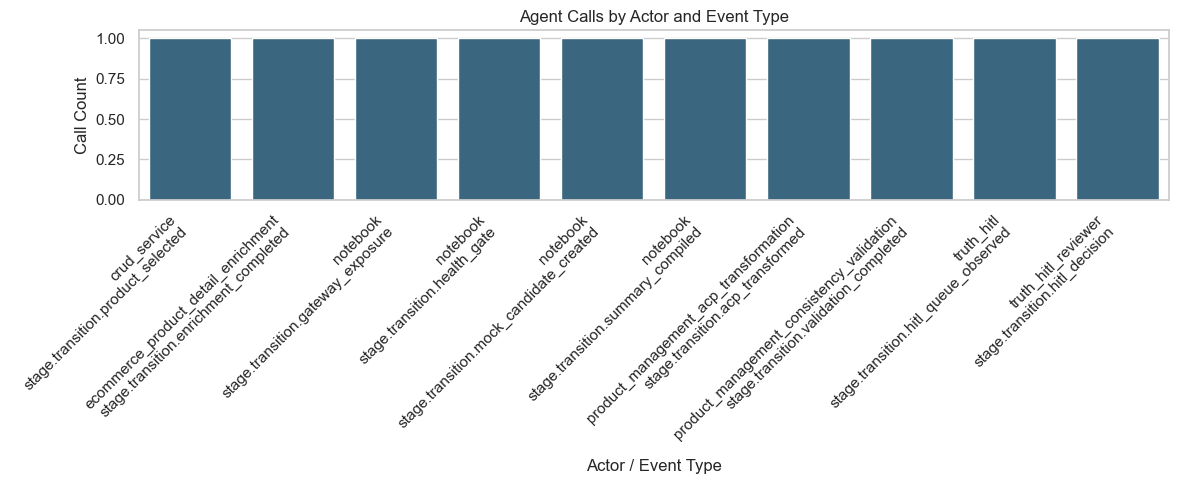

In [186]:
plt.figure(figsize=(12, 5))

if agent_calls_df.empty:
    plt.text(0.5, 0.5, "No agent call events available", ha="center", va="center")
    plt.axis("off")
else:
    chart_df = agent_calls_df.copy()
    chart_df["actor_event"] = chart_df["actor"] + "\n" + chart_df["event_type"]
    chart_df = chart_df.head(20)

    if sns is not None:
        sns.barplot(data=chart_df, x="actor_event", y="count", color="#2F6B8A")
    else:
        plt.bar(chart_df["actor_event"], chart_df["count"], color="#2F6B8A")

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Call Count")
    plt.xlabel("Actor / Event Type")
    plt.title("Agent Calls by Actor and Event Type")

plt.tight_layout()
plt.show()

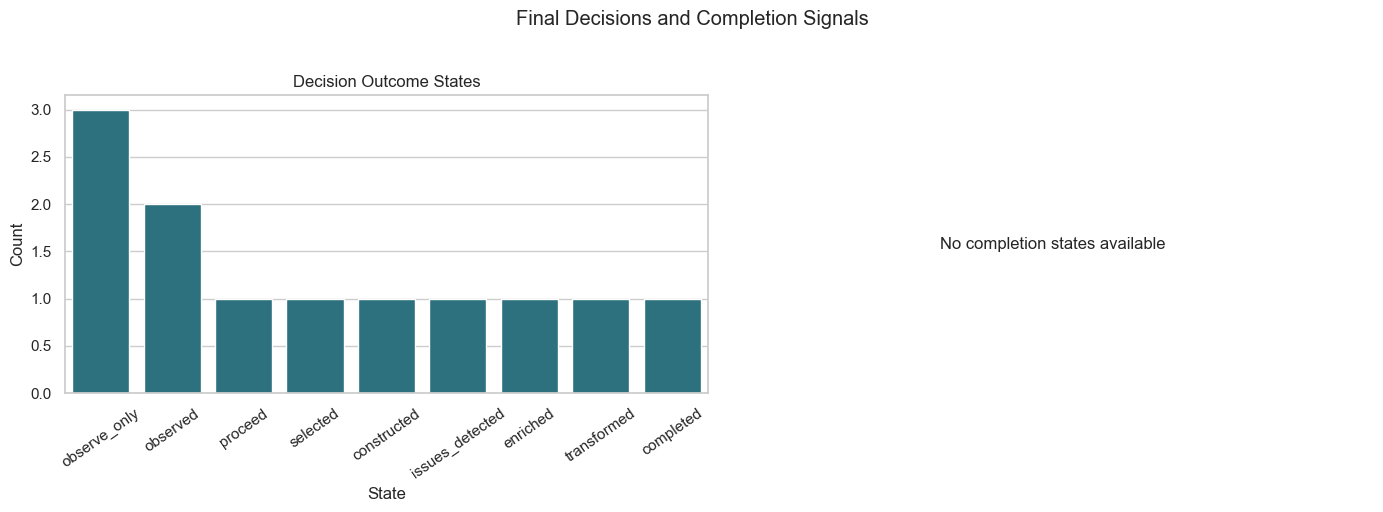

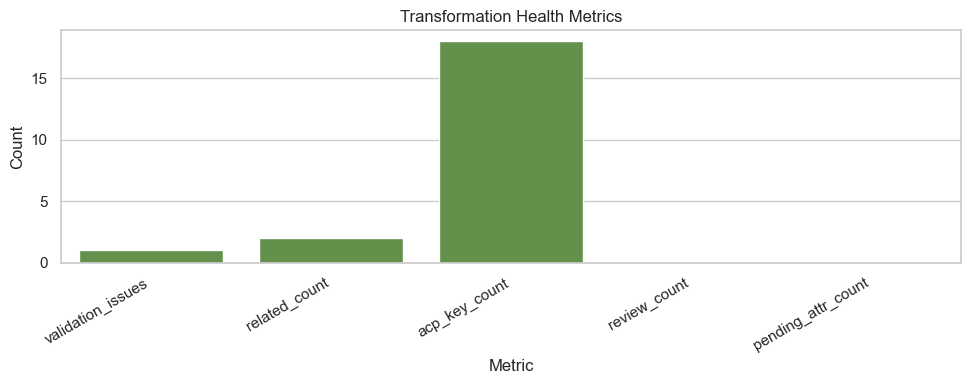

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, kind, title, color in [
    (axes[0], "decision", "Decision Outcome States", "#1f7a8c"),
    (axes[1], "completion", "Completion States", "#bf7f2f"),
]:
    subset = states_df[states_df["kind"] == kind] if not states_df.empty else pd.DataFrame()
    if subset.empty:
        ax.text(0.5, 0.5, f"No {kind} states available", ha="center", va="center")
        ax.axis("off")
        continue

    state_counts = (
        subset["state"]
        .value_counts(dropna=False)
        .rename_axis("state")
        .reset_index(name="count")
    )

    if sns is not None:
        sns.barplot(data=state_counts, x="state", y="count", color=color, ax=ax)
    else:
        ax.bar(state_counts["state"], state_counts["count"], color=color)

    ax.set_title(title)
    ax.set_xlabel("State")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=35)

fig.suptitle("Final Decisions and Completion Signals", y=1.02)
fig.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
if transform_metrics_df.empty:
    plt.text(0.5, 0.5, "No transformation metrics available", ha="center", va="center")
    plt.axis("off")
else:
    if sns is not None:
        sns.barplot(data=transform_metrics_df, x="metric", y="value", color="#5f9c3f")
    else:
        plt.bar(transform_metrics_df["metric"], transform_metrics_df["value"], color="#5f9c3f")

    plt.xticks(rotation=30, ha="right")
    plt.xlabel("Metric")
    plt.ylabel("Count")
    plt.title("Transformation Health Metrics")

plt.tight_layout()
plt.show()

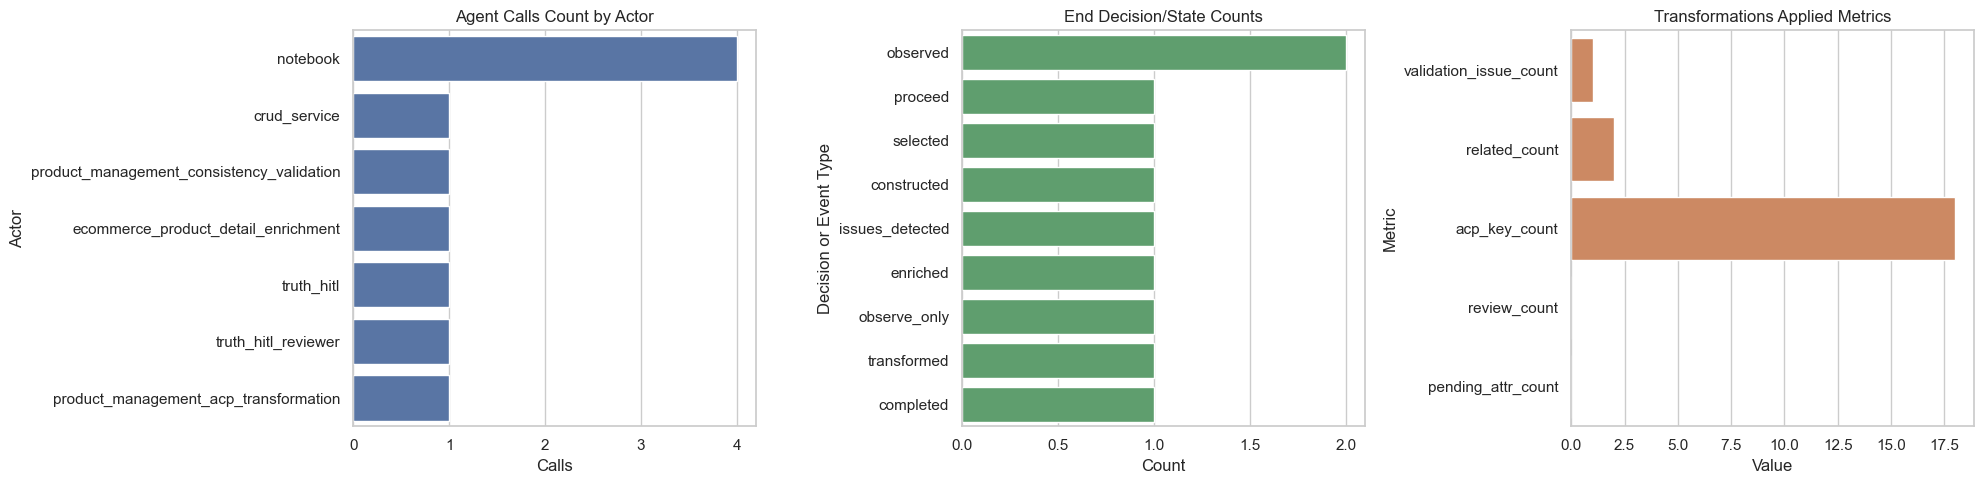

Monitoring charts rendered from metadata successfully.
                metric  value
validation_issue_count    1.0
         related_count    2.0
         acp_key_count   18.0
          review_count    0.0
    pending_attr_count    0.0


In [188]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid')


def _to_event_frame(summary: dict | None, timeline_obj: object) -> pd.DataFrame:
    timeline = []
    if isinstance(summary, dict):
        candidate = summary.get('event_timeline', [])
        if isinstance(candidate, list):
            timeline = candidate
    if (not timeline) and isinstance(timeline_obj, list):
        timeline = timeline_obj

    rows = [item for item in timeline if isinstance(item, dict)]
    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    if 'actor' not in df.columns:
        df['actor'] = 'unknown_actor'
    if 'decision' not in df.columns:
        df['decision'] = None
    if 'event_type' not in df.columns:
        df['event_type'] = 'unknown_event'
    if 'quality' not in df.columns:
        df['quality'] = [{} for _ in range(len(df))]
    return df


def _safe_numeric(value: object, default: float = 0.0) -> float:
    try:
        if value is None:
            return default
        if isinstance(value, bool):
            return float(int(value))
        return float(value)
    except (TypeError, ValueError):
        return default


def _metric_from_sources(metric: str, summary: dict | None, event_df: pd.DataFrame) -> float:
    if isinstance(summary, dict):
        results = summary.get('results', {})
        if isinstance(results, dict) and metric in results:
            return _safe_numeric(results.get(metric))

    global_value = globals().get(metric)
    if global_value is not None:
        return _safe_numeric(global_value)

    extracted = []
    for quality in event_df.get('quality', pd.Series(dtype='object')):
        if isinstance(quality, dict) and metric in quality:
            extracted.append(_safe_numeric(quality.get(metric)))

    if extracted:
        return max(extracted)
    return 0.0


summary_obj = final_summary if isinstance(globals().get('final_summary'), dict) else {}
timeline_obj = globals().get('event_timeline', [])

events_df = _to_event_frame(summary_obj, timeline_obj)

if events_df.empty:
    print('No event metadata is available to chart yet. Run the pipeline cells first.')
else:
    actor_series = events_df['actor'].fillna('unknown_actor').astype(str)

    end_state_series = events_df['decision'].fillna(events_df['event_type'])
    end_state_series = end_state_series.fillna('unknown_state').astype(str)

    transform_metric_names = [
        'validation_issue_count',
        'related_count',
        'acp_key_count',
        'review_count',
        'pending_attr_count',
    ]
    transform_metrics_df = pd.DataFrame(
        {
            'metric': transform_metric_names,
            'value': [
                _metric_from_sources(metric, summary_obj, events_df)
                for metric in transform_metric_names
            ],
        }
    )

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    actor_counts = actor_series.value_counts().reset_index()
    actor_counts.columns = ['actor', 'calls']
    sns.barplot(data=actor_counts, x='calls', y='actor', ax=axes[0], color='#4C72B0')
    axes[0].set_title('Agent Calls Count by Actor')
    axes[0].set_xlabel('Calls')
    axes[0].set_ylabel('Actor')

    state_counts = end_state_series.value_counts().reset_index()
    state_counts.columns = ['state', 'count']
    sns.barplot(data=state_counts, x='count', y='state', ax=axes[1], color='#55A868')
    axes[1].set_title('End Decision/State Counts')
    axes[1].set_xlabel('Count')
    axes[1].set_ylabel('Decision or Event Type')

    sns.barplot(
        data=transform_metrics_df,
        x='value',
        y='metric',
        ax=axes[2],
        color='#DD8452',
    )
    axes[2].set_title('Transformations Applied Metrics')
    axes[2].set_xlabel('Value')
    axes[2].set_ylabel('Metric')

    plt.tight_layout()
    plt.show()

    print('Monitoring charts rendered from metadata successfully.')
    print(transform_metrics_df.to_string(index=False))

## Stage 12 - Executive Pitch Pack

### Why
Leaders need a repeatable narrative that explains value, control, and scalability in minutes.
A pitch pack turns complex execution into a decision-ready story for sponsors and partners.

### How
The stage compiles architecture intent, delivery evidence, governance posture, and measurable outcomes into one brief.
It prioritizes business language while retaining traceability to implementation artifacts.

### What
The output is a concise executive package suitable for steering committees, funding reviews, and go-live checkpoints.
It emphasizes outcomes, confidence, and next-step readiness.

### Measurable Signal
Shorter approval cycles and fewer clarification requests indicate the pitch pack is effectively structured.

### Documentation Links
- [Business Scenarios README](docs/business_scenarios/README.md)
- [Architecture Business Summary](docs/architecture/business-summary.md)
- [Implementation Roadmap](docs/IMPLEMENTATION_ROADMAP.md)

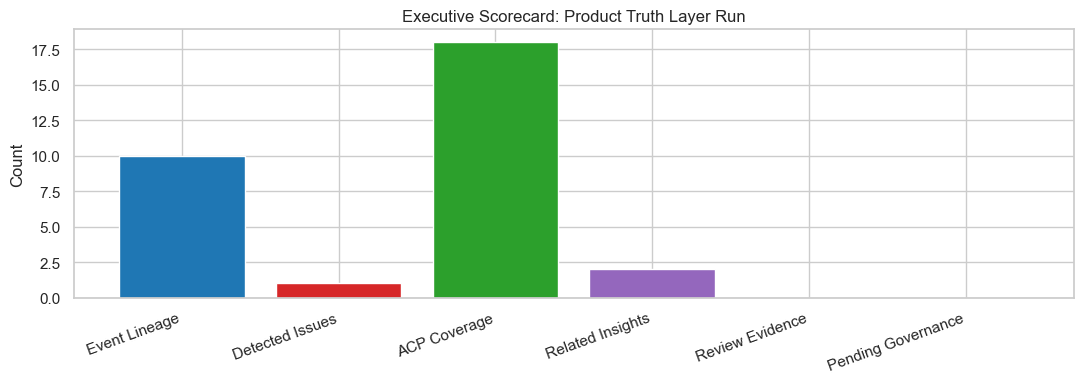

Executive scorecard metrics:
- Event Lineage: 10
- Detected Issues: 1
- ACP Coverage: 18
- Related Insights: 2
- Review Evidence: 0
- Pending Governance: 0


In [189]:
# Executive scorecard chart for sponsor conversations
import matplotlib.pyplot as plt

events_count = len(event_timeline) if isinstance(globals().get('event_timeline'), list) else 0
issues_count = len(validation_issues) if isinstance(globals().get('validation_issues'), list) else 0
acp_count = len(acp_keys) if isinstance(globals().get('acp_keys'), list) else 0
related_count = len(related_items) if isinstance(globals().get('related_items'), list) else 0
review_count = len(reviews) if isinstance(globals().get('reviews'), list) else 0
pending_count = len((hitl_decision_outcome or {}).get('pending_attr_ids', []) or [])

scorecard = {
    'Event Lineage': events_count,
    'Detected Issues': issues_count,
    'ACP Coverage': acp_count,
    'Related Insights': related_count,
    'Review Evidence': review_count,
    'Pending Governance': pending_count,
}

plt.figure(figsize=(11, 4))
plt.bar(scorecard.keys(), scorecard.values(), color=['#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e', '#8c564b'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Count')
plt.title('Executive Scorecard: Product Truth Layer Run')
plt.tight_layout()
plt.show()

print('Executive scorecard metrics:')
for k, v in scorecard.items():
    print(f'- {k}: {v}')

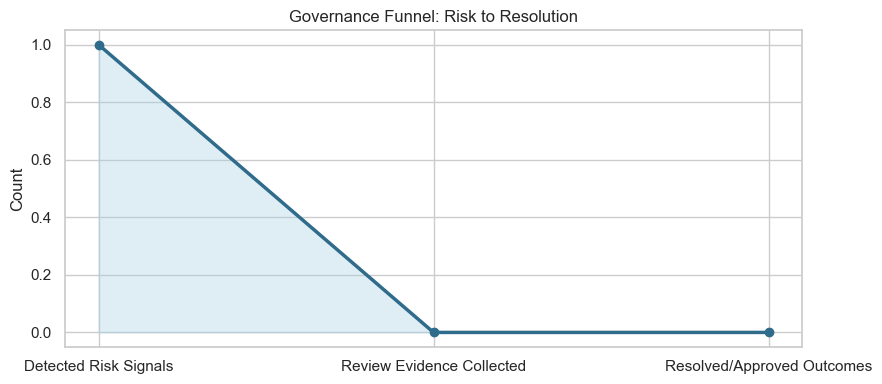

Governance narrative:
- Decision path: observe_only
- Pending governance attributes: 0
- Resolved/approved indicator: 0


In [190]:
# Governance funnel view: risk detection to disposition
import matplotlib.pyplot as plt

decision = (hitl_decision_outcome or {}).get('decision', 'observe_only')
issues_count = len(validation_issues) if isinstance(globals().get('validation_issues'), list) else 0
review_count = len(reviews) if isinstance(globals().get('reviews'), list) else 0
pending_count = len((hitl_decision_outcome or {}).get('pending_attr_ids', []) or [])

approved_like = 1 if decision in {'approve', 'edit_and_approve'} else 0
resolved_like = max(review_count - pending_count, 0) + approved_like

funnel_labels = ['Detected Risk Signals', 'Review Evidence Collected', 'Resolved/Approved Outcomes']
funnel_values = [issues_count, review_count, resolved_like]

plt.figure(figsize=(9, 4))
plt.plot(funnel_labels, funnel_values, marker='o', linewidth=2.5, color='#2f6b8a')
plt.fill_between(range(len(funnel_values)), funnel_values, color='#a6cee3', alpha=0.35)
plt.ylabel('Count')
plt.title('Governance Funnel: Risk to Resolution')
plt.tight_layout()
plt.show()

print('Governance narrative:')
print(f'- Decision path: {decision}')
print(f'- Pending governance attributes: {pending_count}')
print(f'- Resolved/approved indicator: {resolved_like}')

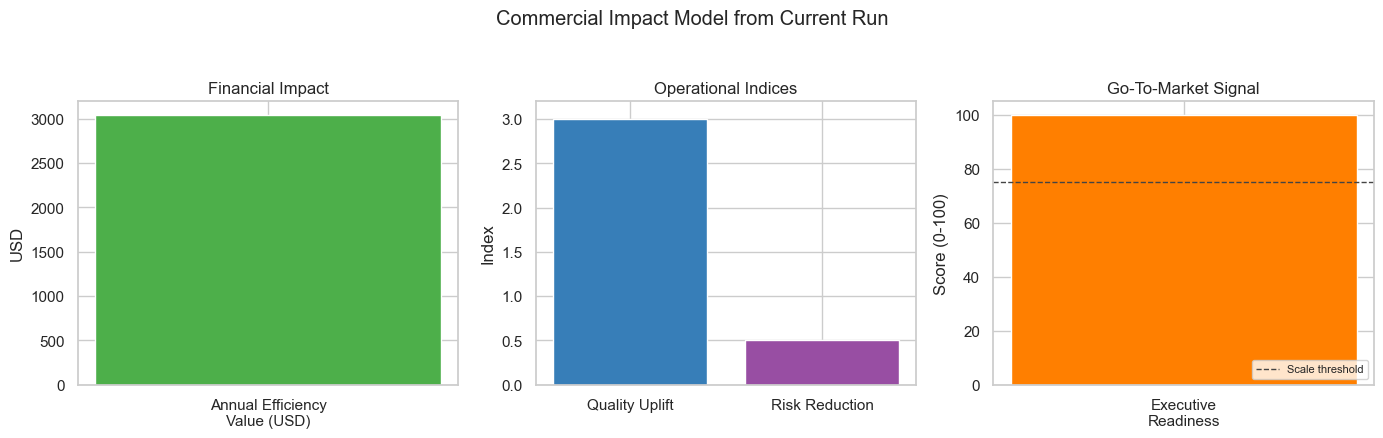

Pitch assumptions:
- Estimated hours saved per month: 3.9
- Assumed blended hourly cost: $65.00
Modeled outputs:
- Annual efficiency value: $3,042
- Quality uplift index: 3.00
- Risk reduction index: 0.50
- Executive readiness score: 100.0/100


In [191]:
# Modeled annual value potential for sales storytelling
import matplotlib.pyplot as plt

issues_count = len(validation_issues) if isinstance(globals().get('validation_issues'), list) else 0
acp_count = len(acp_keys) if isinstance(globals().get('acp_keys'), list) else 0
related_count = len(related_items) if isinstance(globals().get('related_items'), list) else 0
events_count = len(event_timeline) if isinstance(globals().get('event_timeline'), list) else 0

# Conservative demonstration assumptions for pitch scenarios.
hours_saved_month = max(issues_count * 0.8 + acp_count * 0.15 + related_count * 0.2, 1.0)
hourly_cost = 65.0
annual_efficiency_value = hours_saved_month * 12 * hourly_cost

quality_uplift_index = max(min((acp_count + related_count) / max(issues_count + 1, 1), 3.0), 0.2)
risk_reduction_index = max(min(events_count / 20.0, 2.5), 0.2)
executive_readiness_score = min(100.0, round((quality_uplift_index * 35) + (risk_reduction_index * 25) + 30, 1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

axes[0].bar(['Annual Efficiency\nValue (USD)'], [annual_efficiency_value], color='#4daf4a')
axes[0].set_title('Financial Impact')
axes[0].set_ylabel('USD')

axes[1].bar(['Quality Uplift', 'Risk Reduction'], [quality_uplift_index, risk_reduction_index], color=['#377eb8', '#984ea3'])
axes[1].set_title('Operational Indices')
axes[1].set_ylabel('Index')
axes[1].set_ylim(0, 3.2)

axes[2].bar(['Executive\nReadiness'], [executive_readiness_score], color='#ff7f00')
axes[2].axhline(75, linestyle='--', color='#444444', linewidth=1, label='Scale threshold')
axes[2].set_title('Go-To-Market Signal')
axes[2].set_ylabel('Score (0-100)')
axes[2].set_ylim(0, 105)
axes[2].legend(loc='lower right', fontsize=8)

fig.suptitle('Commercial Impact Model from Current Run', y=1.04)
fig.tight_layout()
plt.show()

print('Pitch assumptions:')
print(f'- Estimated hours saved per month: {hours_saved_month:.1f}')
print(f'- Assumed blended hourly cost: ${hourly_cost:.2f}')
print('Modeled outputs:')
print(f'- Annual efficiency value: ${annual_efficiency_value:,.0f}')
print(f'- Quality uplift index: {quality_uplift_index:.2f}')
print(f'- Risk reduction index: {risk_reduction_index:.2f}')
print(f'- Executive readiness score: {executive_readiness_score:.1f}/100')